# Greedy-OMP : Mirror-Prox **online** pour MFG (sans MetaCURL)

Version online de l'algorithme Mirror-Prox + Prox-$\Gamma$ du rapport (Algos 1–2), dans le cas
« de base » : **$P$ indépendant de $\mu$ et stationnaire**, mais **$P$ et $r$ inconnus du learner**.
Pas de méta-algorithme ici : juste les outils online élémentaires, en suivant le protocole de Greedy MD-CURL (Moreno et al., 2024) :

| Ingrédient | Rôle | Origine |
|---|---|---|
| Estimation $\hat P^t$ par moyenne empirique du bruit ($g$ connue) | apprendre le modèle | Greedy MD-CURL, Eq. (11) |
| Ré-ancrage : $\tilde\pi^t = (1-\alpha_t)\pi^{\mathrm{base}} + \alpha_t/\|\mathcal{A}\|$, redéroulé sous $\hat P^t$ | la référence du prox doit vivre dans le polytope courant $\mathcal{K}^{\hat P^t}_\xi$, qui change à chaque épisode ; le mixage garantit $\pi^{\mathrm{ref}} > 0$ | Greedy MD-CURL, Eq. (13) |
| Itération Mirror-Prox complète (extrapolation + correction) par épisode | anticipation de la foule, stabilité | Algo 1 du rapport |
| Moyenne de Polyak-Ruppert incrémentale $\bar d^t$, la population joue $\bar\pi^t$ | Proche de **Fictitious Play** où la foule affrontée est le flot moyen des flots passés | Perrin et al. (FP) / Nemirovski |


**Hypothèses** (héritées de Greedy MD-CURL) : dynamique $s_{h+1} = g_h(s_h, a_h, \varepsilon_h)$ avec
$g$ **connue** et bruit externe $\varepsilon \sim h$ **inconnu mais stationnaire** ; le learner observe
$\varepsilon^t_h$ ; la récompense $r$ est révélée en fin d'épisode **comme fonction de $\mu$** (c'est ce
qui permet les deux évaluations de l'opérateur $F(d) = -r(\cdot,\mu^d)$, au point courant et au point
extrapolé, sinon on dégénère en Mirror Descent).

**Deux variantes de politique jouée**, toutes deux suivies dans le code ci-dessous :
- l'**itéré glouton** $\pi^{t+1/2}$ (politique du demi-pas) : c'est l'objet qu'analyse le cadre regret
  de Moreno, à garder si les pertes deviennent adversariales ;
- la **moyenne** $\bar\pi^t$ (politique de $\bar d^t = \frac1t\sum_q d^{q+1/2}$) : le lissage
  cohérent avec la garantie de Nemirovski (qui porte sur la moyenne des demi-pas).

**Environnement** : même grille quatre pièces + congestion $r_h(s,a,\mu) = -c\,\mu_h(s)$ (opérateur
monotone, MFNE unique) que le notebook model-based. **Métrique** : exploitabilité sous le **vrai** $P$. Pour l'unicité, en effet on a la stricte monotonicité de $F$, $\langle -(-c\mu) + (-c\mu'), \mu - \mu' \rangle = c \| \mu - \mu'\|^2 > 0$ dès que $\mu \neq \mu'$. On est même dans un cas potentiel : $r = - \nabla \frac{c}{2} \| \mu \|^2$.

In [1]:
import numpy as np
from scipy.special import logsumexp, softmax
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Environnement : quatre pièces + décomposition en bruit externe

Le `slip` du notebook model-based se réécrit exactement dans le formalisme $g(s, a, \varepsilon)$ :
$\varepsilon \in \{0, \dots, n_A - 1\}$ (« poussé » vers le mouvement $\varepsilon$) $\cup\,\{n_A\}$
(« aucune interférence », on exécute $a$), avec $h(n_A) = 1 - \mathrm{slip}$ et $h(e) = \mathrm{slip}/n_A$.
On le vérifie numériquement ci-dessous. $g$ = table de déplacement `step_idx` (connue) ; seule la loi
$h$ du bruit est à apprendre.

In [2]:
ACTIONS = np.array([(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)])  # stay,up,down,left,right

def build_four_room(n=11):
    mid = n // 2
    doors = {(mid, 2), (mid, n - 3), (2, mid), (n - 3, mid)}
    blocked = set()
    for c in range(n):
        if (mid, c) not in doors: blocked.add((mid, c))
    for r in range(n):
        if (r, mid) not in doors: blocked.add((r, mid))
    cells = [(r, c) for r in range(n) for c in range(n) if (r, c) not in blocked]
    cell_to_idx = {cell: i for i, cell in enumerate(cells)}
    coords = np.array(cells)
    nS, nA = len(cells), len(ACTIONS)
    step_idx = np.zeros((nS, nA), dtype=int)          # g : table de deplacement (CONNUE)
    for s, (r, c) in enumerate(cells):
        for a in range(nA):
            dr, dc = ACTIONS[a]
            step_idx[s, a] = cell_to_idx.get((r + dr, c + dc), s)
    return step_idx, coords, cell_to_idx, (n, n), blocked

def true_noise_dist(slip, nA):
    '''Loi h du bruit externe (INCONNUE du learner).'''
    h = np.full(nA + 1, slip / nA); h[nA] = 1.0 - slip
    return h

def kernel_from_noise(h_noise, step_idx):
    '''P[a,s,s'] = h(nA) delta_{step(s,a)} + sum_e h(e) delta_{step(s,e)}.
    Seul endroit ou g intervient : g connue => P determine par h.'''
    nS, nA = step_idx.shape
    P = np.zeros((nA, nS, nS)); ss = np.arange(nS)
    for a in range(nA):
        np.add.at(P[a], (ss, step_idx[:, a]), h_noise[nA])
        for e in range(nA):
            np.add.at(P[a], (ss, step_idx[:, e]), h_noise[e])
    return P

step_idx, coords, c2i, grid_shape, blocked = build_four_room(n=11)
nS, nA = step_idx.shape
h_true = true_noise_dist(slip=0.05, nA=nA)
P_true = kernel_from_noise(h_true, step_idx)          # simulation + evaluation SEULEMENT
print(f"grille {grid_shape} | nS={nS} | nA={nA} | bruit : {nA+1} categories")

# verification : coincide avec la construction slip du notebook model-based
def build_P_notebook(n=11, slip=0.05):
    mid = n // 2
    doors = {(mid, 2), (mid, n - 3), (2, mid), (n - 3, mid)}; blk = set()
    for c in range(n):
        if (mid, c) not in doors: blk.add((mid, c))
    for r in range(n):
        if (r, mid) not in doors: blk.add((r, mid))
    cells = [(r, c) for r in range(n) for c in range(n) if (r, c) not in blk]
    idx = {cell: i for i, cell in enumerate(cells)}
    nS_, nA_ = len(cells), len(ACTIONS)
    def step(r, c, a):
        dr, dc = ACTIONS[a]; return idx.get((r + dr, c + dc), idx[(r, c)])
    P = np.zeros((nA_, nS_, nS_))
    for s, (r, c) in enumerate(cells):
        outs = [step(r, c, a) for a in range(nA_)]
        for a in range(nA_):
            P[a, s, outs[a]] += 1 - slip
            for a2 in range(nA_): P[a, s, outs[a2]] += slip / nA_
    return P / P.sum(2, keepdims=True)

print("noyau (g,h) == noyau slip du model-based :", np.allclose(P_true, build_P_notebook()))

grille (11, 11) | nS=104 | nA=5 | bruit : 6 categories
noyau (g,h) == noyau slip du model-based : True


## 2. Briques MFG (identiques au notebook model-based)

`prox_gamma` est l'Algo 2 du pseudo-code (Prox-$\Gamma$ **dans le MDP estimé** : $\hat P$ en argument).

In [13]:
def make_reward(nS, nA, c_cong=1.0):
    def reward(mu_h):                       # mu_h:(nS,) -> r:(nS,nA)
        return np.repeat((-c_cong * mu_h)[:, None], nA, axis=1)
    return reward

def forward_unroll(pi, P, xi, H):
    nS, nA = pi.shape[1], pi.shape[2]
    d = np.zeros((H, nS, nA)); bar_d = np.zeros((H, nS)); bar_d[0] = xi / H
    for h in range(H - 1):
        d[h] = bar_d[h][:, None] * pi[h]
        bar_d[h + 1] = np.einsum('sa,asx->x', d[h], P)
    d[H - 1] = bar_d[H - 1][:, None] * pi[H - 1]
    return d, bar_d

def policy_of(d, eps=1e-12):
    bar = d.sum(axis=2)
    pi = d / np.maximum(bar[:, :, None], eps); pi[bar < eps] = 1.0 / d.shape[2]
    return pi

def prox_gamma(mu, d_ref, gam, P, xi, reward, eps=1e-12):
    '''Prox-Gamma(mu, d_ref, gamma, P_hat) : arg min <-gam r(.,mu), d> + Gamma(d, d_ref)
    sur K^{P}_xi (forme fermee, Algo 2 du pseudo-code).'''
    H, nS, nA = d_ref.shape
    log_pi_ref = np.log(np.maximum(policy_of(d_ref, eps), eps))
    pi_new = np.zeros((H, nS, nA)); V_next = np.zeros(nS)
    for h in range(H - 1, -1, -1):
        Q = reward(mu[h]) + np.einsum('asx,x->sa', P, V_next)
        logits = log_pi_ref[h] + gam * Q
        V_next = logsumexp(logits, axis=1) / gam        # soft-value
        pi_new[h] = softmax(logits, axis=1)             # facteur exponentiel
    d_new, _ = forward_unroll(pi_new, P, xi, H)
    return d_new

def exploitability(d, P, xi, reward, eps=1e-12):
    H, nS, nA = d.shape
    mu = H * d.sum(axis=2); pi = policy_of(d, eps)
    V_br = np.zeros(nS); V_pi = np.zeros(nS)
    for h in range(H - 1, -1, -1):
        r_h = reward(mu[h])
        V_br = (r_h + np.einsum('asx,x->sa', P, V_br)).max(axis=1)
        V_pi = (pi[h] * (r_h + np.einsum('asx,x->sa', P, V_pi))).sum(axis=1)
    return float(xi @ (V_br - V_pi))

reward = make_reward(nS, nA, c_cong=1.0)
xi = np.zeros(nS); xi[c2i[(0, 0)]] = 1.0

## 3. Greedy-OMP (Algo 1 du pseudo-code)

Une itération Mirror-Prox complète par épisode, dans le MDP estimé. Les numéros de lignes
renvoient au pseudo-code. Remarque d'implémentation : le bruit étant **externe** (indépendant de
$(s,a)$), son observation ne dépend pas de la politique jouée — l'estimation $\hat P^t$ est donc
identique quelle que soit la variante jouée, ce qui permet d'évaluer dans une seule boucle
l'itéré glouton $\pi^{t+1/2}$ et la moyenne $\bar\pi^t$ sans biaiser la comparaison
(c'est aussi la raison profonde pour laquelle le protocole glouton se passe d'exploration UCRL).

In [4]:
def greedy_omp(step_idx, h_true, xi, reward, H, T, gamma, mode='learn',
               M=1, alpha_fn=lambda t: 1.0 / t, seed=0, snap_episodes=(), verbose=False):
    '''mode="learn"  : P_hat estime en ligne (Greedy-OMP proprement dit)
       mode="known"  : P_hat = P vrai (oracle)
       mode="frozen" : P_hat fige a g(.,.,"aucun bruit") (jamais appris)'''
    nS, nA = step_idx.shape
    rng = np.random.default_rng(seed)
    P_true = kernel_from_noise(h_true, step_idx)

    noise_counts = np.zeros(nA + 1)                                   # (l. 2)
    if mode == 'known':
        P_hat = P_true
    elif mode == 'frozen':
        h0 = np.zeros(nA + 1); h0[nA] = 1.0
        P_hat = kernel_from_noise(h0, step_idx)
    else:
        P_hat = kernel_from_noise(np.full(nA + 1, 1.0 / (nA + 1)), step_idx)

    pi_base = np.full((H, nS, nA), 1.0 / nA)                          # (l. 2)
    bar_d = np.zeros((H, nS, nA))
    hist = {'exp_half': [], 'exp_avg': [], 'P_err': [], 'snaps': {}}

    for t in range(1, T + 1):
        # --- re-ancrage : mixage d'exploration + deroule dans K^{P_hat^t}   (l. 4-6)
        a_t = alpha_fn(t)
        pi_tilde = (1.0 - a_t) * pi_base + a_t / nA
        d_tilde, _ = forward_unroll(pi_tilde, P_hat, xi, H)
        mu_t = H * d_tilde.sum(axis=2)                                # (l. 8)

        # --- demi-pas d'extrapolation                                       (l. 9-10)
        d_half = prox_gamma(mu_t, d_tilde, gamma, P_hat, xi, reward)
        mu_half = H * d_half.sum(axis=2)                              # (l. 11-12)
        # --- pas de correction (meme reference d_tilde)                     (l. 13-14)
        d_full = prox_gamma(mu_half, d_tilde, gamma, P_hat, xi, reward)
        pi_base = policy_of(d_full)                                   # (l. 15)

        # --- moyenne de Polyak-Ruppert incrementale (damping FP)            (l. 17)
        bar_d = (t - 1) / t * bar_d + d_half / t
        pi_bar = policy_of(bar_d)
        pi_half = policy_of(d_half)

        # --- jeu de l'episode : la population joue bar_pi^t                 (l. 18-21)
        for _ in range(M):
            s = rng.choice(nS, p=xi)
            for h in range(H):
                a = rng.choice(nA, p=pi_bar[h, s])
                eps = rng.choice(nA + 1, p=h_true)
                noise_counts[eps] += 1
                s = step_idx[s, a] if eps == nA else step_idx[s, eps]

        # --- (r^{t+1} revele : stationnaire ici)                            (l. 22-23)
        # --- mise a jour gloutonne du noyau estime                          (l. 24-25)
        if mode == 'learn':
            P_hat = kernel_from_noise(noise_counts / noise_counts.sum(), step_idx)

        # --- suivi sous le VRAI modele (les deux variantes)
        d_pl_half, _ = forward_unroll(pi_half, P_true, xi, H)
        d_pl_bar, _ = forward_unroll(pi_bar, P_true, xi, H)
        hist['exp_half'].append(exploitability(d_pl_half, P_true, xi, reward))
        hist['exp_avg'].append(exploitability(d_pl_bar, P_true, xi, reward))
        hist['P_err'].append(float(np.abs(P_hat - P_true).sum(axis=2).max()))
        if t in snap_episodes:
            hist['snaps'][t] = d_pl_bar.copy()
        if verbose and (t <= 3 or t % max(1, T // 8) == 0):
            print(f"  [{mode}] ep {t:4d} | exp(pi^(t+1/2))={hist['exp_half'][-1]:.3e}"
                  f" | exp(bar_pi^t)={hist['exp_avg'][-1]:.3e}"
                  f" | ||P_hat-P||={hist['P_err'][-1]:.3e}")
    return pi_bar, bar_d, hist

## 4. Référence model-based (Algo 1 et 2 du rapport, $P$ et $r$ connus)

In [5]:
def mirror_prox_model_based(P, xi, reward, H, K, gamma):
    nS, nA = P.shape[1], P.shape[0]
    pi0 = np.full((H, nS, nA), 1.0 / nA)
    d_k, _ = forward_unroll(pi0, P, xi, H)
    sum_half = np.zeros((H, nS, nA)); exp_half, exp_avg = [], []
    for k in range(1, K + 1):
        mu_k = H * d_k.sum(axis=2)
        d_half = prox_gamma(mu_k, d_k, gamma, P, xi, reward)
        mu_half = H * d_half.sum(axis=2)
        d_k = prox_gamma(mu_half, d_k, gamma, P, xi, reward)
        sum_half += d_half
        exp_half.append(exploitability(d_half, P, xi, reward))
        exp_avg.append(exploitability(sum_half / k, P, xi, reward))
    return sum_half / K, np.array(exp_half), np.array(exp_avg)

## 5. Expérience ($H = 30$, $T = 300$ épisodes, $M = 1$ agent/épisode, $\gamma = 1$)

$\gamma$ redevient ici un hyperparamètre (le $\gamma = 1/(\sqrt2 L)$ de Nemirovski exige $L$, inconnue
en ligne) : on prend $\gamma = 1$, le pas identifié comme stable dans l'étude $\gamma$ vs $H$ du
notebook model-based. C'est précisément ce réglage que la grille $\Lambda$ de MetaCURL rendra
*parameter-free* dans l'étape suivante. Environ 1 minute d'exécution.

In [6]:
H, T, gamma = 30, 300, 1.0
snap_eps = (1, 5, 25, 100, T)

pi_bar_T, bar_d_T, hist = greedy_omp(step_idx, h_true, xi, reward, H, T, gamma,
                                     mode='learn', seed=0, snap_episodes=snap_eps, verbose=True)
_, _, hist_kn = greedy_omp(step_idx, h_true, xi, reward, H, T, gamma, mode='known', seed=1)
_, _, hist_fr = greedy_omp(step_idx, h_true, xi, reward, H, T, gamma, mode='frozen', seed=2)
d_mb, eh_mb, ea_mb = mirror_prox_model_based(P_true, xi, reward, H, T, gamma)

print(f"\nfinal :")
print(f"  Greedy-OMP  exp(pi^(T+1/2)) = {hist['exp_half'][-1]:.3e} | exp(bar_pi^T) = {hist['exp_avg'][-1]:.3e}")
print(f"  P connu     exp             = {hist_kn['exp_half'][-1]:.3e}")
print(f"  P fige      exp             = {hist_fr['exp_half'][-1]:.3e}")
print(f"  model-based exp(demi-pas)   = {eh_mb[-1]:.3e}")
print(f"  ||P_hat - P|| final         = {hist['P_err'][-1]:.3e}")

  [learn] ep    1 | exp(pi^(t+1/2))=2.095e+00 | exp(bar_pi^t)=2.095e+00 | ||P_hat-P||=9.333e-02
  [learn] ep    2 | exp(pi^(t+1/2))=1.477e+00 | exp(bar_pi^t)=1.745e+00 | ||P_hat-P||=7.333e-02
  [learn] ep    3 | exp(pi^(t+1/2))=1.315e+00 | exp(bar_pi^t)=1.581e+00 | ||P_hat-P||=5.333e-02
  [learn] ep   37 | exp(pi^(t+1/2))=3.403e-01 | exp(bar_pi^t)=6.243e-01 | ||P_hat-P||=1.910e-02
  [learn] ep   74 | exp(pi^(t+1/2))=2.216e-01 | exp(bar_pi^t)=4.268e-01 | ||P_hat-P||=8.468e-03
  [learn] ep  111 | exp(pi^(t+1/2))=1.610e-01 | exp(bar_pi^t)=3.392e-01 | ||P_hat-P||=7.147e-03
  [learn] ep  148 | exp(pi^(t+1/2))=1.244e-01 | exp(bar_pi^t)=2.855e-01 | ||P_hat-P||=7.928e-03
  [learn] ep  185 | exp(pi^(t+1/2))=1.014e-01 | exp(bar_pi^t)=2.477e-01 | ||P_hat-P||=7.748e-03
  [learn] ep  222 | exp(pi^(t+1/2))=8.301e-02 | exp(bar_pi^t)=2.198e-01 | ||P_hat-P||=4.144e-03
  [learn] ep  259 | exp(pi^(t+1/2))=7.461e-02 | exp(bar_pi^t)=1.976e-01 | ||P_hat-P||=5.946e-03
  [learn] ep  296 | exp(pi^(t+1/2))=6.23

## 6. Convergence de l'exploitabilité (analogue section 7 du notebook model-based)

Lecture attendue :
- l'**itéré glouton** $\pi^{t+1/2}$ de Greedy-OMP décroît en $\approx O(1/t)$ et **rattrape le cas
  $P$ connu** en quelques épisodes : l'estimation gloutonne du noyau ne coûte presque rien (avantage
  du cadre bruit externe, phénomène de la Fig. 4 de Moreno) ;
- **ne jamais apprendre le bruit plafonne** (biais de modèle irréductible) ;
- la **moyenne FP** $\bar\pi^t$ est plus lisse mais plus lente en environnement stationnaire : elle
  traîne le biais des premiers itérés (uniformes). Son intérêt est la robustesse — c'est l'objet sur
  lequel porte la garantie de Nemirovski, et le bon choix si l'opérateur n'est que simplement monotone
  (oscillations possibles de l'itéré) ;
- le model-based reste le plus rapide : l'écart avec Greedy-OMP mesure le coût total de l'incertitude
  (erreur $\hat P^t$ + apprentissage de $r$ + ré-ancrage dans un polytope mouvant).

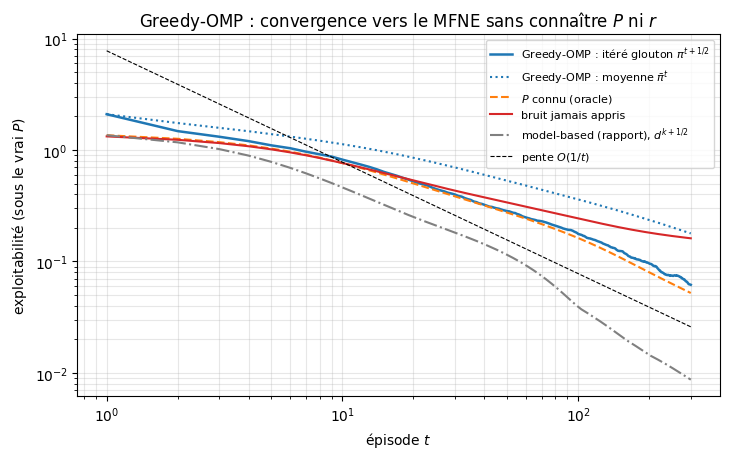

In [15]:
ts = np.arange(1, T + 1)
fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.loglog(ts, hist['exp_half'], color='C0', lw=1.8, label=r'Greedy-OMP : itéré glouton $\pi^{t+1/2}$')
ax.loglog(ts, hist['exp_avg'], color='C0', ls=':', label=r'Greedy-OMP : moyenne $\bar\pi^t$')
ax.loglog(ts, hist_kn['exp_half'], color='C1', ls='--', label=r'$P$ connu (oracle)')
ax.loglog(ts, hist_fr['exp_half'], color='C3', label='bruit jamais appris')
ax.loglog(ts, eh_mb, color='gray', ls='-.', label=r'model-based (rapport), $d^{k+1/2}$')
ax.loglog(ts, np.array(hist['exp_half'])[10] / (ts / 10), '--', color='k', lw=.8, label=r'pente $O(1/t)$')
ax.set_xlabel('épisode $t$'); ax.set_ylabel('exploitabilité (sous le vrai $P$)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=.3)
ax.set_title('Greedy-OMP : convergence vers le MFNE sans connaître $P$ ni $r$')
fig.tight_layout(); plt.show()

## 7. Estimation du noyau

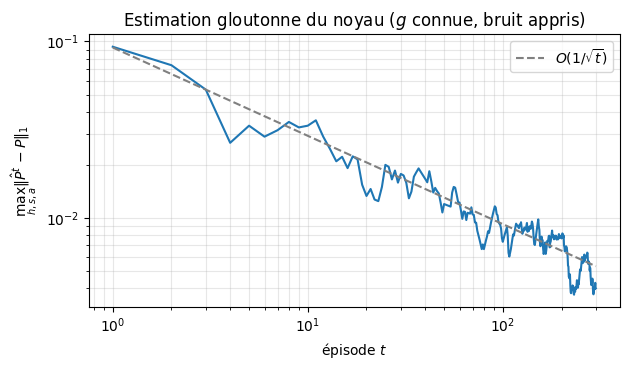

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.loglog(ts, hist['P_err'], color='C0')
ax.loglog(ts, hist['P_err'][2] / np.sqrt(ts / 3), '--', color='gray', label=r'$O(1/\sqrt{t})$')
ax.set_xlabel('épisode $t$'); ax.set_ylabel(r'$\max_{h,s,a}\|\hat P^t - P\|_1$')
ax.set_title(r'Estimation gloutonne du noyau ($g$ connue, bruit appris)')
ax.legend(); ax.grid(True, which='both', alpha=.3)
fig.tight_layout(); plt.show()

## 8. Flot champ moyen au MFNE (analogue section 8)

La foule diffuse à travers les portes pour fuir la congestion — alors que ni $P$ ni $r$ n'ont jamais
été fournis à l'algorithme.

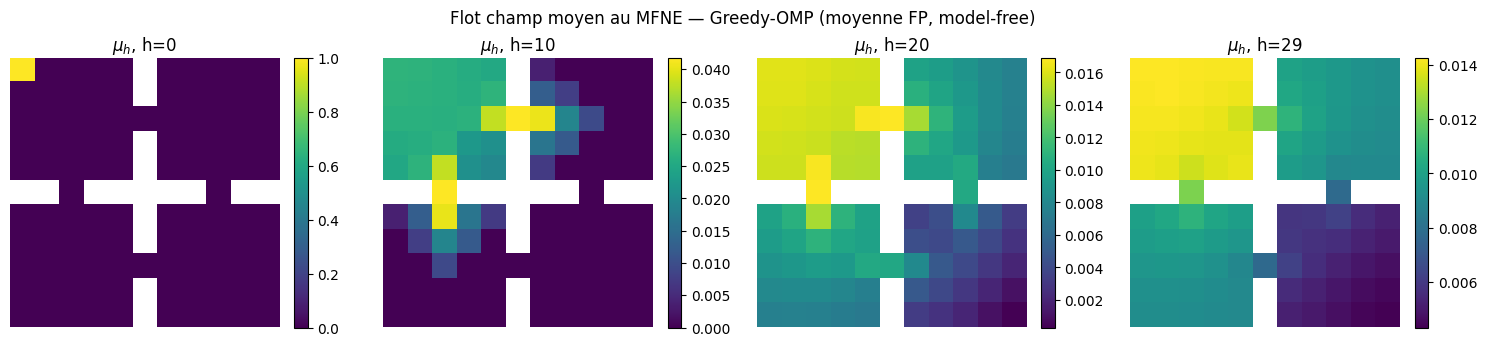

In [9]:
def to_grid(vec, coords, shape):
    g = np.full(shape, np.nan)
    for i, (r, c) in enumerate(coords): g[r, c] = vec[i]
    return g

mu_bar = H * bar_d_T.sum(axis=2)
hs = [0, H // 3, 2 * H // 3, H - 1]
fig, axes = plt.subplots(1, len(hs), figsize=(15, 3.4))
for ax, h in zip(axes, hs):
    im = ax.imshow(to_grid(mu_bar[h], coords, grid_shape), cmap='viridis')
    ax.set_title(f'$\\mu_h$, h={h}'); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Flot champ moyen au MFNE — Greedy-OMP (moyenne FP, model-free)')
fig.tight_layout(); plt.show()

## 9. Convergence du flot au fil des épisodes (analogue section 10)

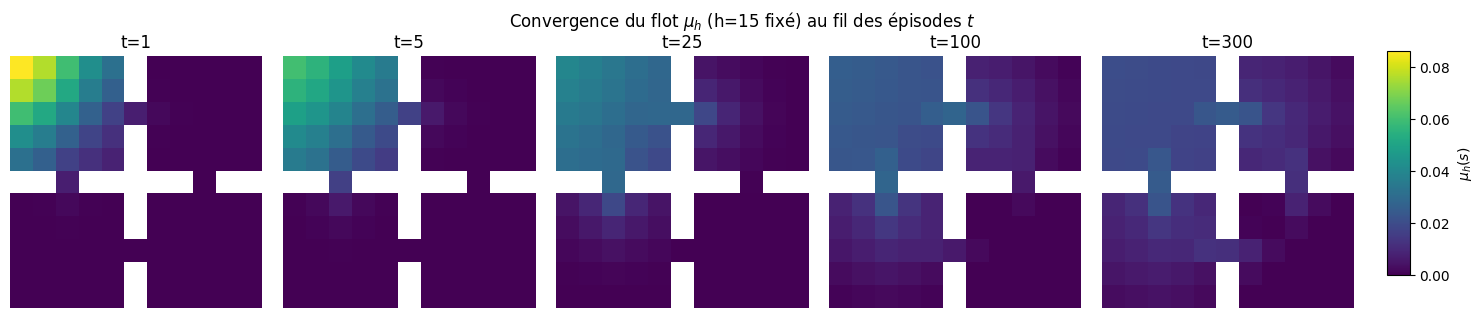

In [10]:
snap_iters = sorted(hist['snaps'].keys())
h_fix = H // 2
fig, axes = plt.subplots(1, len(snap_iters), figsize=(15, 3.2))
vmax = max((H * hist['snaps'][k].sum(2))[h_fix].max() for k in snap_iters)
im = None
for ax, k in zip(axes, snap_iters):
    mu_k = H * hist['snaps'][k].sum(axis=2)
    im = ax.imshow(to_grid(mu_k[h_fix], coords, grid_shape), cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(f't={k}'); ax.axis('off')
fig.suptitle(f'Convergence du flot $\\mu_h$ (h={h_fix} fixé) au fil des épisodes $t$')
fig.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7]); fig.colorbar(im, cax=cax, label=r'$\mu_h(s)$')
plt.show()

## 10. Politique d'équilibre (analogue section 11)

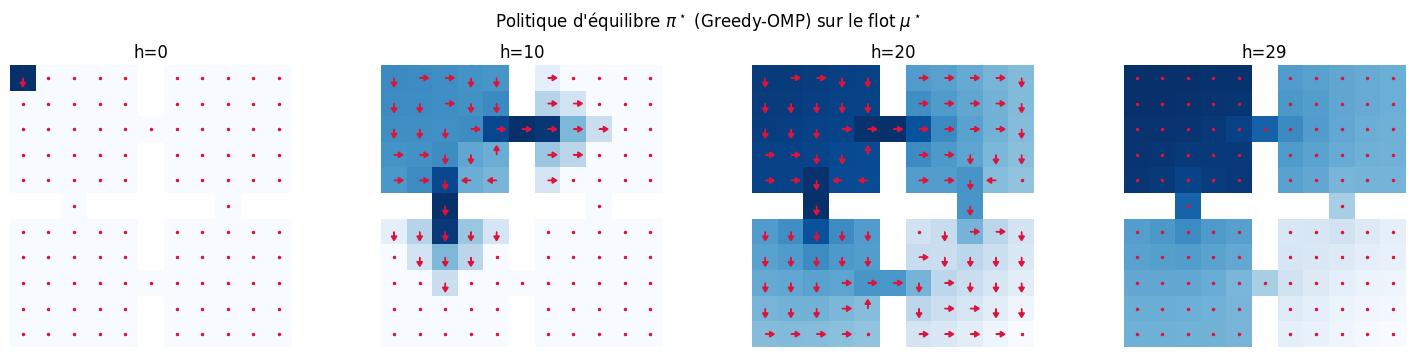

In [11]:
ARROW = {1: (0, -0.35), 2: (0, 0.35), 3: (-0.35, 0), 4: (0.35, 0)}

def plot_policy(ax, pi_h, mu_h, title):
    ax.imshow(to_grid(mu_h, coords, grid_shape), cmap='Blues')
    for i, (r, c) in enumerate(coords):
        a = int(pi_h[i].argmax())
        if a == 0:
            ax.plot(c, r, '.', color='crimson', ms=3)
        else:
            dx, dy = ARROW[a]
            ax.arrow(c, r, dx, dy, head_width=0.22, head_length=0.18,
                     fc='crimson', ec='crimson', length_includes_head=True)
    ax.set_title(title); ax.axis('off')

pi_star = policy_of(bar_d_T)
fig, axes = plt.subplots(1, len(hs), figsize=(15, 3.6))
for ax, h in zip(axes, hs):
    plot_policy(ax, pi_star[h], mu_bar[h], f'h={h}')
fig.suptitle("Politique d'équilibre $\\pi^\\star$ (Greedy-OMP) sur le flot $\\mu^\\star$")
fig.tight_layout(); plt.show()

## 11. Le MFNE model-free coïncide avec le MFNE model-based

On compare le flot de l'**itéré glouton final** $\pi^{T+1/2}$ (déroulé sous le vrai $P$) à l'équilibre
d'un model-based longuement convergé ($K = 800$).

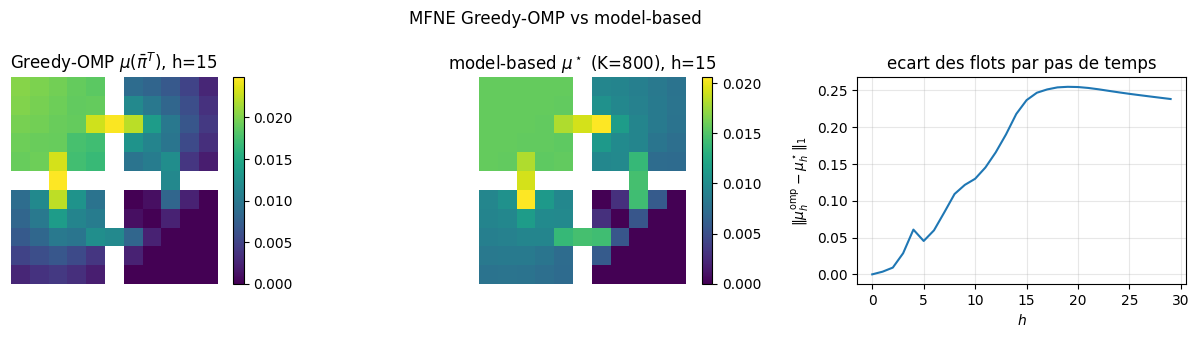

ecart L1 moyen par h : 0.169 | max : 0.255


In [12]:
d_ref, _, ea_ref = mirror_prox_model_based(P_true, xi, reward, H, 800, gamma)
mu_ref = H * d_ref.sum(axis=2)
# flot de la politique moyennee finale (deroulee sous le vrai P)
d_last_bar, _ = forward_unroll(policy_of(bar_d_T), P_true, xi, H)
mu_last = H * d_last_bar.sum(axis=2)
err = np.abs(mu_last - mu_ref).sum(axis=1)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13, 3.4))
im = a1.imshow(to_grid(mu_last[h_fix], coords, grid_shape), cmap='viridis')
a1.set_title(f'Greedy-OMP $\\mu(\\bar\\pi^T)$, h={h_fix}'); a1.axis('off'); fig.colorbar(im, ax=a1, fraction=.046)
im = a2.imshow(to_grid(mu_ref[h_fix], coords, grid_shape), cmap='viridis')
a2.set_title(f'model-based $\\mu^\\star$ (K=800), h={h_fix}'); a2.axis('off'); fig.colorbar(im, ax=a2, fraction=.046)
a3.plot(err); a3.set_xlabel('$h$'); a3.set_ylabel(r'$\|\mu^{\rm omp}_h - \mu^\star_h\|_1$')
a3.set_title('ecart des flots par pas de temps'); a3.grid(alpha=.3)
fig.suptitle('MFNE Greedy-OMP vs model-based')
fig.tight_layout(); plt.show()
print(f"ecart L1 moyen par h : {err.mean():.3f} | max : {err.max():.3f}")

## 12. Bilan

**Ce qu'on observe** (mêmes conclusions qualitatives que le model-based) :
1. **convergence** de l'itéré glouton en $\approx O(1/t)$, quasi indistinguable du cas $P$ connu dès
   quelques épisodes : l'estimation gloutonne du noyau est quasi gratuite (bruit externe, pas d'UCRL) ;
   ne jamais apprendre le bruit plafonne ;
2. **diffusion du champ moyen** et **politique de fuite de la congestion** identiques au model-based ;
   le flot final coïncide avec le MFNE de référence ;
3. **glouton vs moyenne FP** : en environnement stationnaire l'itéré glouton domine (la moyenne traîne
   le biais initial) ; la moyenne FP reste l'objet théoriquement garanti (Nemirovski) et le choix
   robuste si l'opérateur n'est que simplement monotone. Présenter le glouton comme algorithme
   principal, le moyennage comme lissage optionnel.

**Ce qu'il reste à faire (théorie)** : l'analogue du Théorème 5.4 de Moreno pour Greedy-OMP —
$R_T = R^{\mathrm{MDP}}_T + R^{\mathrm{policy}}_T$, avec $R^{\mathrm{MDP}}_T$ traité verbatim par leur
Prop. 5.5, et $R^{\mathrm{policy}}_T$ à refaire avec l'itération Mirror-Prox (mêmes ingrédients :
forte convexité de $\psi$, dérive des polytopes $\|\mu^{\pi,\hat p^t} - \mu^{\pi,\hat p^{t+1}}\|_{\infty,1}
\le 2N/t$ du Lemme 5.6, borne sur $\nabla\psi$ via $\alpha_t$ ; monotonie de Lasry-Lions à la place
de la convexité de $F$). C'est exactement le « regret dynamique Eq. (10) » requis pour brancher
MetaCURL ensuite : **Greedy-OMP est la boîte noire $\mathcal{E}$** de la version méta, rien n'est perdu.

**Limites assumées de cette version de base** : $\gamma$ est un hyperparamètre (MetaCURL le rendra
parameter-free via la grille $\Lambda$) ; le bruit doit être **stationnaire** (la moyenne cumulée
n'oublie jamais — c'est précisément ce qui casse dans le cas non-stationnaire, cf. notebook
MetaCURL-MP-NS où cette baseline reste bloquée après un switch).